## Úloha 4 - chytrý instagramový filtr

Naším úkolem je naprogramovat chytrý instagramový filtr, který umístí nad obličeje korunku, například takto:

![Actress Filter](./data/actress_result.png)

Filtr pro nás bude representován funkcí, jejíž vstupem bude originální barevný obrázek (levo) a výstupem bude stejně velký barevný obrázek, kde bude posazena nad každým obličejem korunka.

## Rozdělení na podúlohy

Pokud pracujeme na komplexní úloze, hodí se vždy ji rozdělit do několika jednodušších kroků, případně nejdřív vytvořit jednoduší verzi řešení a postupně složitost zvyšovat. My budeme postupovat tak, že vyřešíme nejdříve následující podúlohy:

1. nahrajeme obrázek obličeje do proměnné, vykreslíme ho a převedeme z barevného do stupní šedi,
1. použijeme předpřipravený klasifikátor na černobílý obrázek a nalezneme souřadnice tváří v obrázku
1. na základě souřadnic:
    1. zakreslíme do kopie původního obrázku obdelník kolem obličeje
    1. vymažeme z kopie původního obrázku obličej
1. nahrajeme obrázek korunky (pozor na transparentní pozadí) a velikost korunky přizpůsobíme velikosti obličeje
1. upravenou korunku umístíme do kopie původního obrázku nad obličej
1. implementujeme funkci, která provede všechny kroky a vrátí výsledný obrázek

## Import knihoven

In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

## Nahrání obrázku, převod do stupňů šedi a zobrazení

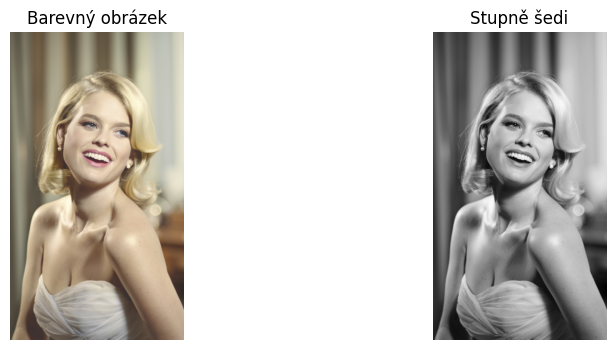

In [2]:
img_path = os.path.join("data", "actress.jpg")
img = cv2.imread(img_path, cv2.IMREAD_COLOR)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Barevný obrázek")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap="gray")
plt.title("Stupně šedi")
plt.axis("off")
plt.show()

## Načtení a použití klasifikátoru

In [3]:
face_classifier_path = os.path.join("classifiers", "haarcascade_frontalface_default.xml")
face_classifier = cv2.CascadeClassifier(face_classifier_path)
faces = face_classifier.detectMultiScale(img_gray)

print(f"Počet obličejů v obrázku: {len(faces)}")
print(f"Jejich souřadnice:\n{faces}")

Počet obličejů v obrázku: 2
Jejich souřadnice:
[[ 361  498  730  730]
 [ 373 2241   54   54]]


## Obdelník kolem obličeje

Obdelník, souřadnice: [361,498], velikost: 730 x 730 pixelů.
Obdelník, souřadnice: [373,2241], velikost: 54 x 54 pixelů.


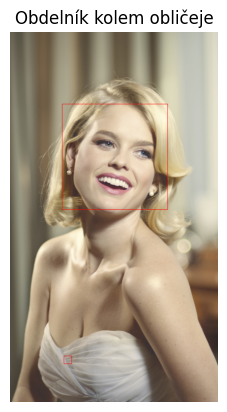

In [4]:
image_boxes = img.copy()
border_color = (0, 0, 255)  # BGR: červená

for face in faces:
    x, y, width, height = face
    print(f"Obdelník, souřadnice: [{x},{y}], velikost: {width} x {height} pixelů.")
    cv2.rectangle(image_boxes, (x, y), (x + width, y + height), border_color, thickness=2)

plt.imshow(cv2.cvtColor(image_boxes, cv2.COLOR_BGR2RGB))
plt.title("Obdelník kolem obličeje")
plt.axis("off")
plt.show()

## Vymazání obličeje

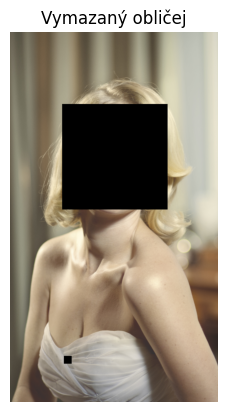

In [5]:
image_no_face = img.copy()
for face in faces:
    x, y, width, height = face
    image_no_face[y:y + height, x:x + width] = 0

plt.imshow(cv2.cvtColor(image_no_face, cv2.COLOR_BGR2RGB))
plt.title("Vymazaný obličej")
plt.axis("off")
plt.show()

## Nahrání a upravení velikosti korunky

Tvar korunky: (3000, 3000, 4)


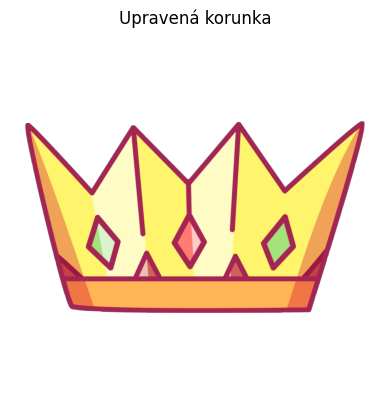

In [6]:
crown_path = os.path.join("data", "crown.png")
crown = cv2.imread(crown_path, cv2.IMREAD_UNCHANGED)  # BGRA
print("Tvar korunky:", crown.shape)

# přizpůsobení šířce prvního nalezeného obličeje
x, y, width, height = faces[0]
scale = width / crown.shape[1]
new_w = width
new_h = int(crown.shape[0] * scale)
crown_resized = cv2.resize(crown, (new_w, new_h), interpolation=cv2.INTER_AREA)

plt.imshow(cv2.cvtColor(crown_resized, cv2.COLOR_BGRA2RGBA))
plt.title("Upravená korunka")
plt.axis("off")
plt.show()

## Přidání korunky do obrázku

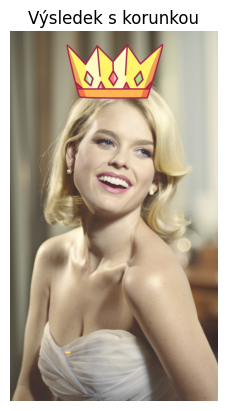

In [7]:
def overlay_bgra(background_bgr, overlay_bgra, x_offset, y_offset):
    """Vloží BGRA obrázek do BGR pozadí s ohledem na alpha kanál."""
    out = background_bgr.copy()
    h, w = overlay_bgra.shape[:2]

    # oříznutí, pokud korunka přesahuje okraj obrázku
    y1, x1 = max(y_offset, 0), max(x_offset, 0)
    y2, x2 = min(y_offset + h, out.shape[0]), min(x_offset + w, out.shape[1])
    oy1, ox1 = y1 - y_offset, x1 - x_offset
    oy2, ox2 = oy1 + (y2 - y1), ox1 + (x2 - x1)

    if y2 <= y1 or x2 <= x1:
        return out

    overlay = overlay_bgra[oy1:oy2, ox1:ox2]
    alpha = overlay[:, :, 3:4].astype(float) / 255.0
    rgb = overlay[:, :, :3].astype(float)
    roi = out[y1:y2, x1:x2].astype(float)
    out[y1:y2, x1:x2] = (alpha * rgb + (1 - alpha) * roi).astype(np.uint8)
    return out


result = img.copy()
for face in faces:
    x, y, width, height = face
    scale = width / crown.shape[1]
    new_w = width
    new_h = int(crown.shape[0] * scale)
    crown_resized = cv2.resize(crown, (new_w, new_h), interpolation=cv2.INTER_AREA)
    # korunka nad obličejem
    y_crown = y - new_h + height // 5
    x_crown = x
    result = overlay_bgra(result, crown_resized, x_crown, y_crown)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Výsledek s korunkou")
plt.axis("off")
plt.show()

## Implementace funkce

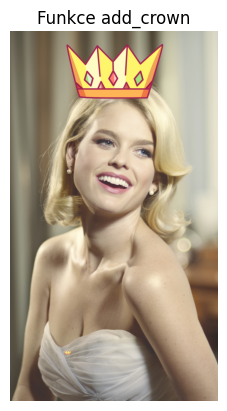

In [8]:
def add_crown(image, crown_path=os.path.join("data", "crown.png"),
              classifier_path=os.path.join("classifiers", "haarcascade_frontalface_default.xml")):
    """Vstup: barevný BGR obrázek. Výstup: stejný obrázek s korunkami nad obličeji."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    classifier = cv2.CascadeClassifier(classifier_path)
    faces = classifier.detectMultiScale(gray)

    crown_full = cv2.imread(crown_path, cv2.IMREAD_UNCHANGED)
    out = image.copy()

    for face in faces:
        x, y, width, height = face
        scale = width / crown_full.shape[1]
        new_w = width
        new_h = int(crown_full.shape[0] * scale)
        crown_resized = cv2.resize(crown_full, (new_w, new_h), interpolation=cv2.INTER_AREA)
        y_crown = y - new_h + height // 5
        out = overlay_bgra(out, crown_resized, x, y_crown)

    return out


filtered = add_crown(img)
plt.imshow(cv2.cvtColor(filtered, cv2.COLOR_BGR2RGB))
plt.title("Funkce add_crown")
plt.axis("off")
plt.show()